### Visión por computador: Ejercicio práctico clase 01


Parte 2: Clasificación de Imágenes

- Encontrar/crear una base de datos de imágenes (2 clases, mínimo 20 imágenes por clase) ok
- Importar la base de datos y visualizar 5 ejemplos por cada clase - pendiente
* Opcional (dividir la base de datos en entrenamiento y prueba)
- Extraemos características de las imágenes
- Creamos un clasificador de imágenes en base a las características extraidas
- Evaluamos el clasificador (al menos una exactitud de 70%)

Entregable:
- Subir el exportado del notebook en formato .ipynb y en formato .pdf.
- También la entrega se puede realizar mediante el enlace al repositorio en GitHub que contenga todos los archivos necesarios para replicar la tarea. El repositorio debe ser público; o si es privado, agregar al usuario @eugeniomorocho como colaborador.

## Grupo 01:

#### Integrantes:

- Jhon Oña
- Ivan Ortega
- Brandon Vega

Para el desarrollo del ejercicio se usó la base de datos The CIFAR-10 dataset: El conjunto de datos CIFAR-10 consta de 60.000 imágenes a color de 32x32 en 10 clases.

Una vez obtenida la base de datos se extrajo 2 tipos clases: aviones y carros. 

In [131]:
import cv2
import numpy as np
import pandas as pd
import os

# Definición de rutas imágenes /Dataset_Cifar/Aviones y /Dataset_Cifar/Carros
carpeta = "Dataset_Cifar" 
clases = ["Aviones", "Carros"]

# Definimos la funcipon para la extración de características
def extraer_caracteristicas_inteligentes(path_imagen):
    img = cv2.imread(path_imagen)
    if img is None: # Validación si la imagen no carga o el archivo está corrupto
        return None
    
    # Imagen a escala de grises
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Característica 1: Nivel de color azul en la imagen
    azul_medio = np.mean(img[:, :, 0])
    
    # Característica 2: Bordes horizontales, se aplica sobel, kernel 3x3
    sobel_h = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)
    bordes_h = np.mean(np.abs(sobel_h))
    
    # Característica 3: Brillo promedio
    brillo = np.mean(img_gris)
    
    # # Caracte´ristica 4:  Textura (Desviación estándar de gris)
    # Mide la variabilidad de intensidad; los carros suelen tener texturas más complejas que el cielo.
    textura = np.std(img_gris)
    
    return [azul_medio, bordes_h, brillo, textura]

### La baja resolución de la base de datos The CIFAR-10(32x32 px) es intencional, ya que permite optimizar la carga computacional del algoritmo KNN y simula escenarios de detección en condiciones de baja visibilidad o ruido extremo.

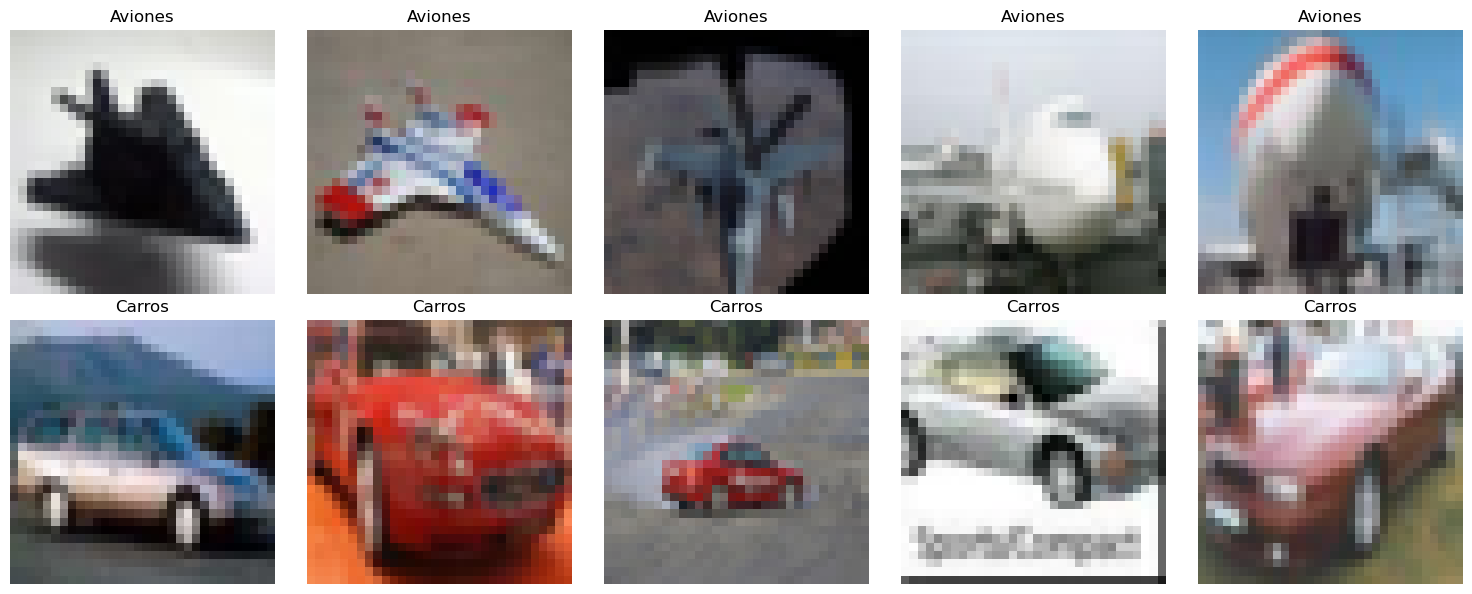

In [134]:
import matplotlib.pyplot as plt


# 2. Preparamos el "lienzo" (2 filas, 5 columnas)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, clase in enumerate(clases):
    ruta_carpeta = os.path.join(carpeta, clase)
    
    # Filtramos los archivos .png y tomamos SOLO LOS PRIMEROS 5
    archivos = [f for f in os.listdir(ruta_carpeta) if f.lower().endswith('.png')][:5]
    
    for j, archivo in enumerate(archivos):
        ruta_img = os.path.join(ruta_carpeta, archivo)
        
        # Leemos la imagen
        img = cv2.imread(ruta_img)
        
        # OJO AQUÍ: OpenCV lee los colores al revés (BGR). 
        # Para que Matplotlib los muestre bien, los pasamos a RGB.
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Dibujamos la imagen en su cuadrícula correspondiente
        axes[i, j].imshow(img_rgb)
        axes[i, j].set_title(f"{clase}")
        axes[i, j].axis('off') # Escondemos los ejes para que se vea más limpio

# Añadimos un título general y mostramos el gráfico
plt.tight_layout()
plt.show()

In [ ]:
extracion_caracteristicas = []

# Recorro las carpetas sw imagenes de Aviones y Carros, extrae características de cada imagen y retorna una lista con los datos procesados.
def procesar_imagenes(carpeta, clases):
    datos_imagen = []
    
    for clase in clases:
        ruta_carpeta = os.path.join(carpeta, clase)
        
        # Obtenemos los nombres de las imágenes de .png
        carga_nombres_imagenes = [f for f in os.listdir(ruta_carpeta) if f.lower().endswith('.png')]

        for imagen in carga_nombres_imagenes:
            # Armo la ruta de la carpeta y nombre de la imagen
            ruta_img = os.path.join(ruta_carpeta, imagen)
            # LLamo a la función definida para obtener las características de la imagen
            caracteristicas = extraer_caracteristicas_inteligentes(ruta_img)
            # Agregamos una columna de la clase a la que corresponde cada imagen
            datos_imagen.append(caracteristicas + [clase])
            #print(datos_imagen)   
    return datos_imagen

extracion_caracteristicas = procesar_imagenes(carpeta, clases)

# Matriz de características
matriz_caracteristicas = pd.DataFrame(extracion_caracteristicas, columns=['Azul', 'Bordes_H', 'Brillo', 'Textura', 'Clase'])


print("Procesamiento Finalizado")
print(f"Total de imágenes procesadas: {len(matriz_caracteristicas)}")
print(matriz_caracteristicas.head())


Procesamiento Finalizado
Total de imágenes procesadas: 120
         Azul    Bordes_H      Brillo    Textura    Clase
0  149.254883  104.834961  148.471680  91.967763  Aviones
1  120.661133   71.657227  126.949219  28.805879  Aviones
2   62.540039   51.015625   58.666992  36.281821  Aviones
3  162.655273   74.859375  162.642578  70.447517  Aviones
4  148.929688   68.535156  132.135742  42.342841  Aviones


In [104]:
# Usamos el código visto en clase en base al ejercicio de clasificación de IRIS
# Aislamos las variables predictoras
X = matriz_caracteristicas.drop('Clase', axis=1)
print("Matriz de Características (X)")
print(X.head())

Matriz de Características (X)
         Azul    Bordes_H      Brillo    Textura
0  149.254883  104.834961  148.471680  91.967763
1  120.661133   71.657227  126.949219  28.805879
2   62.540039   51.015625   58.666992  36.281821
3  162.655273   74.859375  162.642578  70.447517
4  148.929688   68.535156  132.135742  42.342841


In [128]:
# Aislamos la variable objetivo
y = matriz_caracteristicas['Clase']
print("Variable Objetivo (y)")
print(y.head())

Variable Objetivo (y)
0    Aviones
1    Aviones
2    Aviones
3    Aviones
4    Aviones
Name: Clase, dtype: object


In [106]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import joblib
from sklearn.preprocessing import StandardScaler

# Dividimos la base de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Escalamos los datos: Esto hará que los Bordes y la Textura pesen igual que el Azul)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Se utilizó el algortimo k-NN con parámetro 5 vecinos más cercanos para hacer sus predicciones.

In [107]:
# Importamos e instanciamos el modelo k-Nearest Neighbors
classifier = KNeighborsClassifier(n_neighbors=5)

# Entrenamos el modelo
classifier.fit(X_train_scaled, y_train)

# Guardo el modelo entrenado
joblib.dump(classifier, 'knn_model_cifar.pkl')

['knn_model_cifar.pkl']

In [108]:
# Cargo el modelo entrenado
classifier_loaded = joblib.load('knn_model_cifar.pkl')

In [126]:
# Realizamos la predicción en los datos de X_test
y_pred = classifier_loaded.predict(X_test_scaled)


In [137]:
# Calculamos la exactitud para cumplir con el enunciado (min 70%)
from sklearn.metrics import accuracy_score
exactitud = accuracy_score(y_test, y_pred)
print(f"\nExactitud: {exactitud * 100:.2f}%")


Exactitud: 83.33%


Para probrar el modelo creamos un dataframe para comparar

In [118]:
# Tomamos el X_test (las características) y le añadimos la Realidad vs Predicción
comparativa = X_test.copy()
comparativa['Valor_Real'] = y_test
comparativa['Prediccion_IA'] = y_pred

print(comparativa)

           Azul    Bordes_H      Brillo    Textura Valor_Real Prediccion_IA
56   166.484375  113.233398  166.484375  73.082531    Aviones       Aviones
26   136.454102   46.007812  134.622070  39.218697    Aviones       Aviones
118   98.004883  117.348633  109.712891  52.983540     Carros        Carros
54   189.448242   85.504883  171.918945  46.347430    Aviones       Aviones
63   177.759766  187.200195  178.239258  69.281457     Carros        Carros
78    81.866211  111.061523   72.875000  58.709012     Carros        Carros
35   158.832031  109.012695  119.603516  63.179795    Aviones       Aviones
60   116.002930  133.928711  100.835938  56.903053     Carros        Carros
114  107.464844  114.944336  114.346680  40.808288     Carros        Carros
87   114.335938  136.313477  107.270508  45.408326     Carros        Carros
39   139.293945  110.354492  136.472656  58.900416    Aviones       Aviones
109   56.116211  111.647461  116.000000  62.723429     Carros        Carros
107  120.535

In [123]:


# Impirmimos los errores de predicción
errores = comparativa[comparativa['Valor_Real'] != comparativa['Prediccion_IA']]

print(f"El modelo se equivocó en {len(errores)} imágenes")
print(errores)

El modelo se equivocó en 4 imágenes
          Azul    Bordes_H      Brillo    Textura Valor_Real Prediccion_IA
24  151.723633  155.653320  149.337891  54.392859    Aviones        Carros
59  101.664062   80.764648  125.288086  50.519450    Aviones        Carros
42  112.502930   96.186523  110.826172  56.459861    Aviones        Carros
48  142.588867  125.758789  142.378906  61.528583    Aviones        Carros


In [135]:
# Calculamos el reporte de clasificación
from sklearn.metrics import classification_report

# Mostramos el reporte de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Aviones       1.00      0.69      0.82        13
      Carros       0.73      1.00      0.85        11

    accuracy                           0.83        24
   macro avg       0.87      0.85      0.83        24
weighted avg       0.88      0.83      0.83        24



In [136]:
# Importamos la matriz de confusión 
from sklearn.metrics import confusion_matrix

# Calculamos la matriz de confusión con los nombres de las especias
cf_matrix = confusion_matrix(y_test, y_pred)
cf_matrix

array([[ 9,  4],
       [ 0, 11]])

* El modelo K-Nearest Neighbors alcanzó una exactitud del 83.33%. Esto nos indica que las características extraídas son efectivas para discriminar clases.
* La métrica de precisión para la clase Aviones alcanzó un 1.00 (100%). Esto indica la ausencia total de falsos positivos en esta categoría; es decir, cuando el modelo determina que una imagen es un avión, está en lo correcto el 100% de las veces. 
* Análisis de Recall: El modelo tiene un Recall de 1.00 en Carros (encontró absolutamente todos los carros del set de prueba), pero un Recall de 0.69 en Aviones. Al analizar esto con la precisión de Carros (0.73), podemos concluir que el modelo asume que toda imagen con fondos grises o texturas complejas es un vehículo terrestre. 
